In [44]:
import pandas as pd

url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

red = pd.read_csv(url_red, sep=";")
white = pd.read_csv(url_white, sep=";")

Encode color variable to 0/1, the concat the datasets

In [45]:
red["color"] = 0
white["color"] = 1
wine = pd.concat([red, white], ignore_index=True)
wine = wine.sample(frac=1, random_state=1234).reset_index(drop=True)
wine.shape

(6497, 13)

In [46]:
X = wine.drop("quality", axis=1)
y = wine["quality"]
X.shape, y.shape

((6497, 12), (6497,))

In [47]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,color
0,6.0,0.33,0.20,1.80,0.031,49.0,159.0,0.99190,3.41,0.53,11.0,1
1,7.2,0.29,0.20,7.70,0.046,51.0,174.0,0.99582,3.16,0.52,9.5,1
2,6.7,0.47,0.29,4.75,0.034,29.0,134.0,0.99056,3.29,0.46,13.0,1
3,7.6,0.43,0.31,2.10,0.069,13.0,74.0,0.99580,3.26,0.54,9.9,0
4,6.8,0.68,0.09,3.90,0.068,15.0,29.0,0.99524,3.41,0.52,11.1,0


In [48]:
from sklearn.model_selection import train_test_split

seed = 1234

# first split test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=seed,
    stratify=y,
)

# split train / validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=seed,
    stratify=y_train_full,
)

scale X

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# y stays same

In [50]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
classifier = LogisticRegression(solver='lbfgs', fit_intercept=True, max_iter=1000)
classifier.fit(X_train_scaled, y_train)
test_pred = classifier.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)
train_pred = classifier.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)
print("acc of test: ", format(100*test_acc, '.2f') )
print("acc of train: ", format(100*train_acc, '.2f') )

Cs = [0.001, 0.01, 0.1, 1, 10, 100]

acc of test:  56.00
acc of train:  54.04


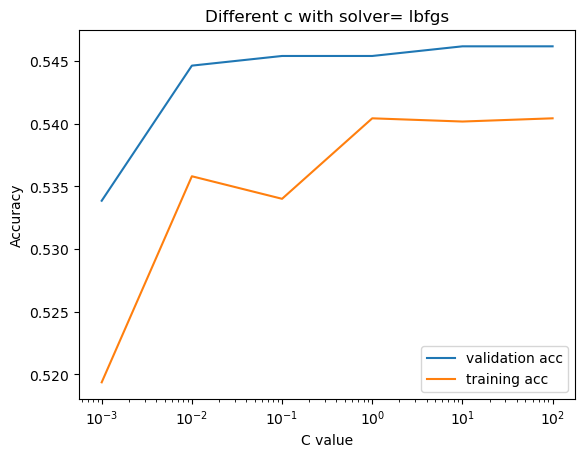

val_acc:  [0.5338461538461539, 0.5446153846153846, 0.5453846153846154, 0.5453846153846154, 0.5461538461538461, 0.5461538461538461]
train_acc:  [0.5193738773415448, 0.535796766743649, 0.5340005132152938, 0.5404157043879908, 0.5401590967410829, 0.5404157043879908]


c:\Users\Zhang\miniconda3\envs\cs178\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Zhang\miniconda3\envs\cs178\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


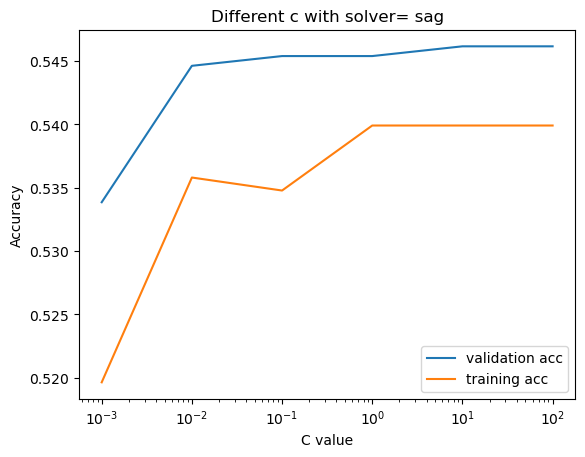

val_acc:  [0.5338461538461539, 0.5446153846153846, 0.5453846153846154, 0.5453846153846154, 0.5461538461538461, 0.5461538461538461]
train_acc:  [0.5196304849884527, 0.535796766743649, 0.5347703361560174, 0.539902489094175, 0.539902489094175, 0.539902489094175]


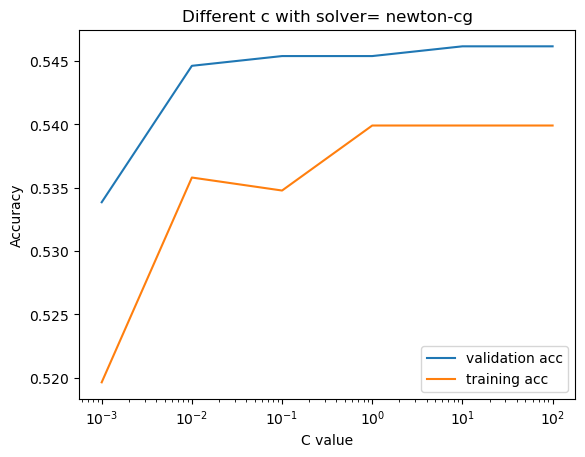

val_acc:  [0.5338461538461539, 0.5446153846153846, 0.5453846153846154, 0.5453846153846154, 0.5461538461538461, 0.5461538461538461]
train_acc:  [0.5196304849884527, 0.535796766743649, 0.5347703361560174, 0.539902489094175, 0.539902489094175, 0.539902489094175]


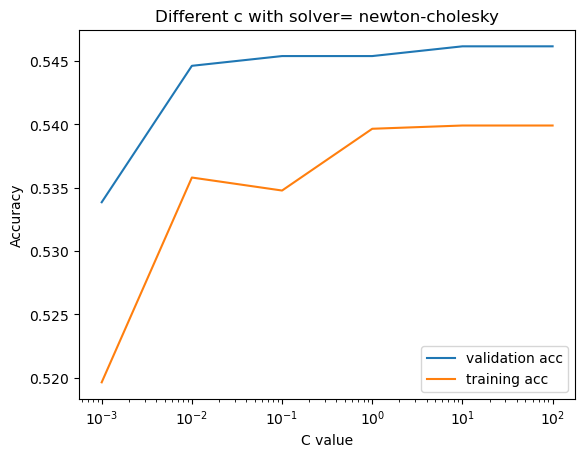

val_acc:  [0.5338461538461539, 0.5446153846153846, 0.5453846153846154, 0.5453846153846154, 0.5461538461538461, 0.5461538461538461]
train_acc:  [0.5196304849884527, 0.535796766743649, 0.5347703361560174, 0.5396458814472671, 0.539902489094175, 0.539902489094175]


c:\Users\Zhang\miniconda3\envs\cs178\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Zhang\miniconda3\envs\cs178\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


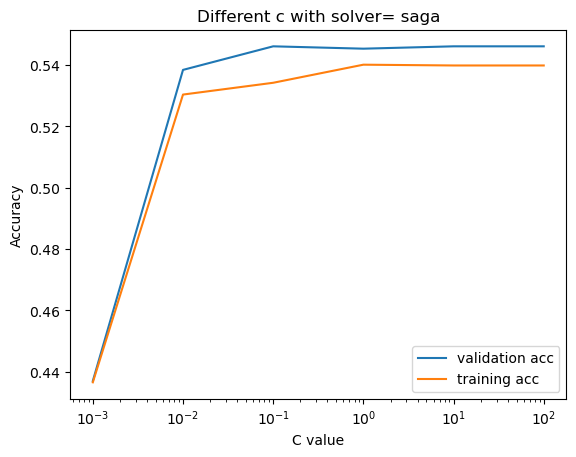

val_acc:  [0.4369230769230769, 0.5384615384615384, 0.5461538461538461, 0.5453846153846154, 0.5461538461538461, 0.5461538461538461]
train_acc:  [0.43648960739030024, 0.5304080061585835, 0.5342571208622017, 0.5401590967410829, 0.539902489094175, 0.539902489094175]


In [59]:
def plot_lr(sol, penal='l2', l1_r=0.0):
    plt.figure()
    plt.title("Different c with solver= " + sol)
    val_accs =[]
    train_accs = []
    test_accs = []
    for c in Cs:
        if(penal != 'l2'):
            classifier = LogisticRegression(solver=sol, penalty=penal, l1_ratio=l1_r, max_iter=1000, C=c)
        else:
            classifier = LogisticRegression(solver=sol, max_iter=1000, C=c)
        classifier.fit(X_train_scaled, y_train)
        test_pred = classifier.predict(X_test_scaled)
        test_acc = accuracy_score(y_test, test_pred)
        train_pred = classifier.predict(X_train_scaled)
        train_acc = accuracy_score(y_train, train_pred)
        val_pred = classifier.predict(X_val_scaled)
        val_acc = accuracy_score(y_val, val_pred)
        val_accs.append(val_acc)
        train_accs.append(train_acc)
        # test_accs.append(test_acc)

        # print("When C =", c, "acc of test: ", format(100*test_acc, '.2f') )
        # print("When C =", c, "acc of train: ", format(100*train_acc, '.2f') )
        # print("When C =", c, "acc of val: ", format(100*val_acc, '.2f') )
    plt.plot(Cs, val_accs, label="validation acc")
    plt.plot(Cs, train_accs, label="training acc")
    plt.ylabel("Accuracy")
    plt.xlabel("C value")
    plt.xscale('log')
    plt.legend()
    plt.show()
    print("val_acc: ", val_accs)
    print("train_acc: ", train_accs)

plot_lr("lbfgs")
plot_lr("sag")
plot_lr("newton-cg")
plot_lr("newton-cholesky")
plot_lr("saga",penal='elasticnet',l1_r=0.5)

c:\Users\Zhang\miniconda3\envs\cs178\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


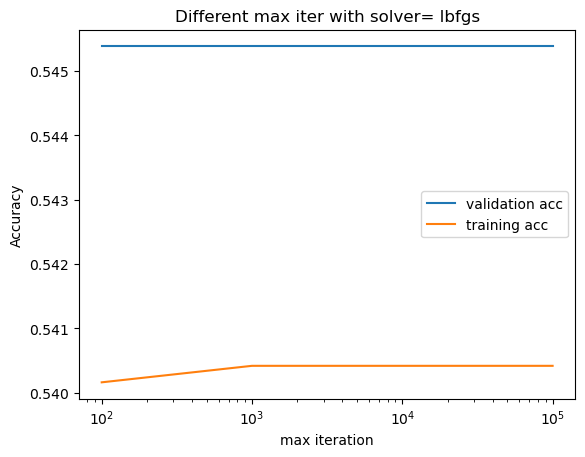

c:\Users\Zhang\miniconda3\envs\cs178\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


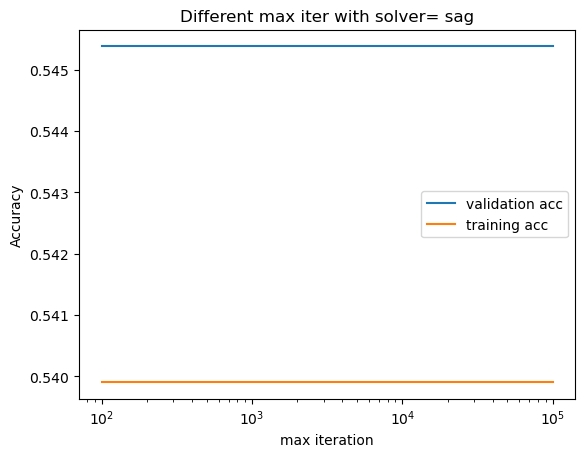

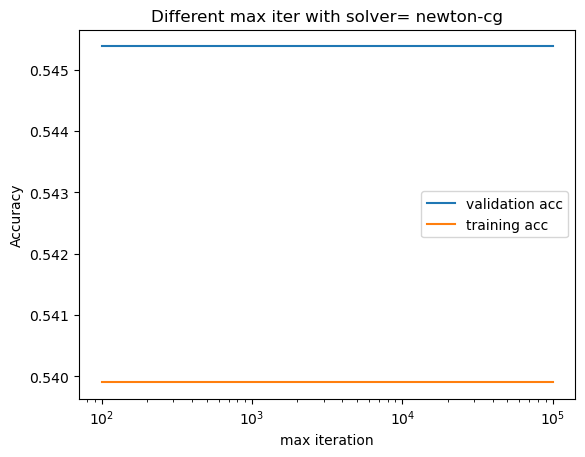

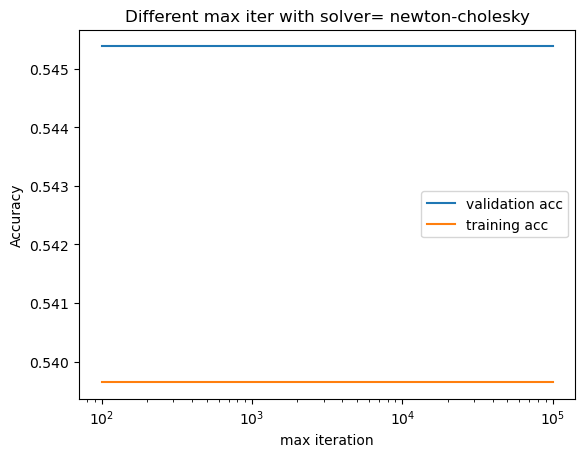

c:\Users\Zhang\miniconda3\envs\cs178\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


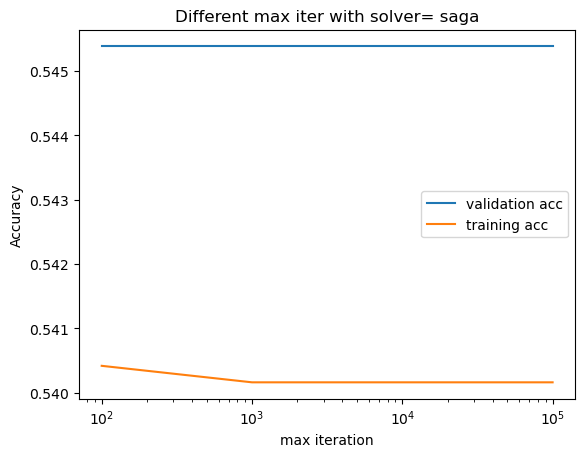

In [60]:
iterations = [100, 1000, 10000, 100000]
def plot_lr(sol, penal='l2', l1_r=0.0):
    plt.figure()
    plt.title("Different max iter with solver= " + sol)
    val_accs =[]
    train_accs = []
    test_accs = []
    for it in iterations:
        if(penal != 'l2'):
            classifier = LogisticRegression(solver=sol, penalty=penal, l1_ratio=l1_r, max_iter=it)
        else:
            classifier = LogisticRegression(solver=sol, max_iter=it)
        classifier.fit(X_train_scaled, y_train)
        test_pred = classifier.predict(X_test_scaled)
        test_acc = accuracy_score(y_test, test_pred)
        train_pred = classifier.predict(X_train_scaled)
        train_acc = accuracy_score(y_train, train_pred)
        val_pred = classifier.predict(X_val_scaled)
        val_acc = accuracy_score(y_val, val_pred)
        val_accs.append(val_acc)
        train_accs.append(train_acc)
        # test_accs.append(test_acc)

        # print("When C =", c, "acc of test: ", format(100*test_acc, '.2f') )
        # print("When C =", c, "acc of train: ", format(100*train_acc, '.2f') )
        # print("When C =", c, "acc of val: ", format(100*val_acc, '.2f') )
    plt.plot(iterations, val_accs, label="validation acc")
    plt.plot(iterations, train_accs, label="training acc")
    plt.ylabel("Accuracy")
    plt.xlabel("max iteration")
    plt.xscale('log')
    plt.legend()
    plt.show()

plot_lr("lbfgs")
plot_lr("sag")
plot_lr("newton-cg")
plot_lr("newton-cholesky")
plot_lr("saga",penal='elasticnet',l1_r=0.5)

For this part, it's obvious that tuning the model with different C or solver would not help with the original dataset.
So what about changing the dataset for logistic_regression?
Logistic_regression works best when the target is categorical, but the current dataset scales from 0-10. From now on 0-5 would be classified as bad(0), while 6-10 would be classified as good(1).


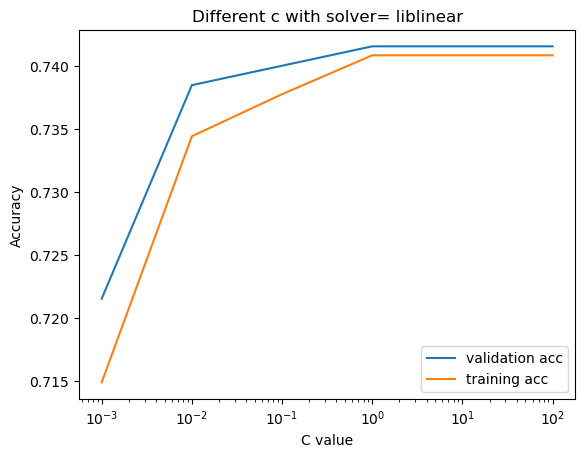

[0.7215384615384616, 0.7384615384615385, 0.74, 0.7415384615384616, 0.7415384615384616, 0.7415384615384616]
[0.7149089042853477, 0.7344110854503464, 0.7377469848601488, 0.7408262766230433, 0.7408262766230433, 0.7408262766230433]


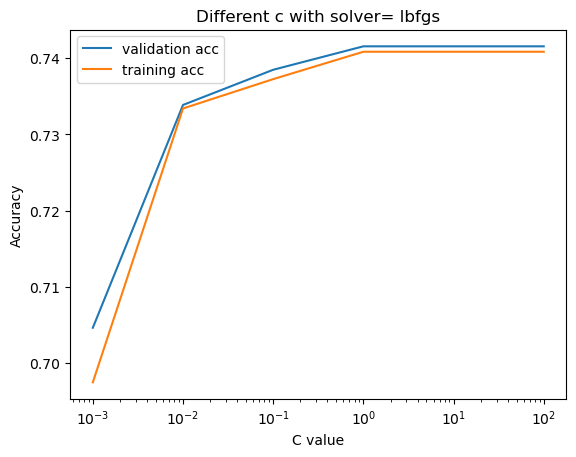

[0.7046153846153846, 0.7338461538461538, 0.7384615384615385, 0.7415384615384616, 0.7415384615384616, 0.7415384615384616]
[0.6974595842956121, 0.7333846548627149, 0.7372337695663331, 0.7408262766230433, 0.7408262766230433, 0.7408262766230433]


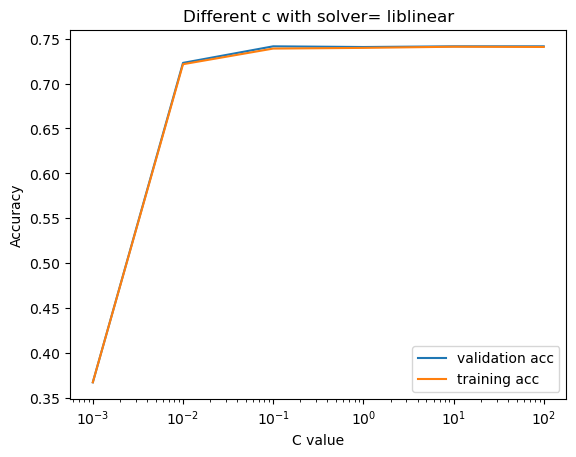

[0.3669230769230769, 0.7230769230769231, 0.7415384615384616, 0.7407692307692307, 0.7415384615384616, 0.7415384615384616]
[0.3669489350782653, 0.7215807031049525, 0.7390300230946882, 0.7397998460354118, 0.7410828842699513, 0.7408262766230433]


In [ ]:
# setup classified y
y_test_cls = (y_test >= 6).astype(int)
y_train_cls = (y_train >= 6).astype(int)
y_val_cls = (y_val >= 6).astype(int)
def plot_lr_cls(sol, penal='l2', l1_r=0.0):
    plt.figure()
    plt.title("Different c with solver= " + sol)
    val_accs =[]
    train_accs = []
    test_accs = []
    for c in Cs:
        if(penal != 'l2'):
            if(sol == 'liblinear'):
                classifier = LogisticRegression(solver=sol, penalty=penal,  max_iter=1000, C=c)
            else:
                classifier = LogisticRegression(solver=sol, penalty=penal, l1_ratio=l1_r, max_iter=1000, C= c)
        else:
            classifier = LogisticRegression(solver=sol, max_iter=1000, C=c)
        classifier.fit(X_train_scaled, y_train_cls)
        test_pred = classifier.predict(X_test_scaled)
        test_acc = accuracy_score(y_test_cls, test_pred)
        train_pred = classifier.predict(X_train_scaled)
        train_acc = accuracy_score(y_train_cls, train_pred)
        val_pred = classifier.predict(X_val_scaled)
        val_acc = accuracy_score(y_val_cls, val_pred)
        val_accs.append(val_acc)
        train_accs.append(train_acc)
        # test_accs.append(test_acc)

        # print("When C =", c, "acc of test: ", format(100*test_acc, '.2f') )
        # print("When C =", c, "acc of train: ", format(100*train_acc, '.2f') )
        # print("When C =", c, "acc of val: ", format(100*val_acc, '.2f') )
    plt.plot(Cs, val_accs, label="validation acc")
    plt.plot(Cs, train_accs, label="training acc")
    plt.ylabel("Accuracy")
    plt.xlabel("C value")
    plt.xscale('log')
    plt.legend()
    plt.show()
    print(val_accs)
    print(train_accs)
plot_lr_cls('liblinear')
plot_lr_cls('lbfgs')
plot_lr_cls('liblinear', penal="l1")

As shown above, the performance is higher when the target value is classified into binary, but comes with a loss that the scale is lost. In conclusion, Logistic Regression is not suitable for this dataset.
Below are other tests for this dataset.

In [54]:
# now testing acc if red and white are tested separatedly
X_red = red.drop('quality', axis=1)
y_red = red["quality"]
# print(X_red[:10])
print(X_red.shape)
# print(y_red[:10])
print(y_red.shape)
X_white = white.drop('quality', axis=1)
y_white = white["quality"]
# print(X_white[:10])
print(X_white.shape)
# print(y_white[:10])
print(y_white.shape)

(1599, 12)
(1599,)
(4898, 12)
(4898,)


In [55]:
X_red_train_full, X_red_test, y_red_train_full, y_red_test = train_test_split(
    X_red,
    y_red,
    test_size=0.2,
    random_state=seed,
    stratify=y_red,
)

# split train / validation
X_red_train, X_red_val, y_red_train, y_red_val = train_test_split(
    X_red_train_full,
    y_red_train_full,
    test_size=0.25,
    random_state=seed,
    stratify=y_red_train_full,
)

scaler = StandardScaler()

X_red_train_scaled = scaler.fit_transform(X_red_train)
X_red_val_scaled = scaler.transform(X_red_val)
X_red_test_scaled = scaler.transform(X_red_test)
Cs = [0.001, 0.01, 0.1, 1, 10, 100]
for c in Cs:
    classifier = LogisticRegression(solver='lbfgs', fit_intercept=True, max_iter=1000)
    classifier.fit(X_red_train_scaled, y_red_train)
    test_pred = classifier.predict(X_red_test_scaled)
    test_acc = accuracy_score(y_red_test, test_pred)
    train_pred = classifier.predict(X_red_train_scaled)
    train_acc = accuracy_score(y_red_train, train_pred)
    train_pred = classifier.predict(X_red_train_scaled)
    train_acc = accuracy_score(y_red_train, train_pred)
    val_pred = classifier.predict(X_red_val_scaled)
    val_acc = accuracy_score(y_red_val, val_pred)
    print("When C =", c, "acc of test: ", format(100*test_acc, '.2f') )
    print("When C =", c, "acc of train: ", format(100*train_acc, '.2f') )
    print("When C =", c, "acc of val: ", format(100*val_acc, '.2f') )

When C = 0.001 acc of test:  55.00
When C = 0.001 acc of train:  61.31
When C = 0.001 acc of val:  62.19
When C = 0.01 acc of test:  55.00
When C = 0.01 acc of train:  61.31
When C = 0.01 acc of val:  62.19
When C = 0.1 acc of test:  55.00
When C = 0.1 acc of train:  61.31
When C = 0.1 acc of val:  62.19
When C = 1 acc of test:  55.00
When C = 1 acc of train:  61.31
When C = 1 acc of val:  62.19
When C = 10 acc of test:  55.00
When C = 10 acc of train:  61.31
When C = 10 acc of val:  62.19
When C = 100 acc of test:  55.00
When C = 100 acc of train:  61.31
When C = 100 acc of val:  62.19


In [ ]:
# now white
X_white_train_full, X_white_test, y_white_train_full, y_white_test = train_test_split(
    X_white,
    y_white,
    test_size=0.2,
    random_state=seed,
    stratify=y_white,
)

# split train / validation
X_white_train, X_white_val, y_white_train, y_white_val = train_test_split(
    X_white_train_full,
    y_white_train_full,
    test_size=0.25,
    random_state=seed,
    stratify=y_white_train_full,
)

scaler = StandardScaler()

X_white_train_scaled = scaler.fit_transform(X_white_train)
X_white_val_scaled = scaler.transform(X_white_val)
X_white_test_scaled = scaler.transform(X_white_test)
Cs = [0.001, 0.01, 0.1, 1, 10, 100]
for c in Cs:
    classifier = LogisticRegression(solver='lbfgs', fit_intercept=True, max_iter=1000)
    classifier.fit(X_white_train_scaled, y_white_train)
    test_pred = classifier.predict(X_white_test_scaled)
    test_acc = accuracy_score(y_white_test, test_pred)
    train_pred = classifier.predict(X_white_train_scaled)
    train_acc = accuracy_score(y_white_train, train_pred)
    val_pred = classifier.predict(X_white_val_scaled)
    val_acc = accuracy_score(y_white_val, val_pred)
    print("When C =", c, "acc of test: ", format(100*test_acc, '.2f') )
    print("When C =", c, "acc of train: ", format(100*train_acc, '.2f') )
    print("When C =", c, "acc of val: ", format(100*val_acc, '.2f') )

When C = 0.001 acc of test:  52.76
When C = 0.001 acc of train:  54.32
When C = 0.001 acc of val:  53.98
When C = 0.01 acc of test:  52.76
When C = 0.01 acc of train:  54.32
When C = 0.01 acc of val:  53.98
When C = 0.1 acc of test:  52.76
When C = 0.1 acc of train:  54.32
When C = 0.1 acc of val:  53.98
When C = 1 acc of test:  52.76
When C = 1 acc of train:  54.32
When C = 1 acc of val:  53.98
When C = 10 acc of test:  52.76
When C = 10 acc of train:  54.32
When C = 10 acc of val:  53.98
When C = 100 acc of test:  52.76
When C = 100 acc of train:  54.32
When C = 100 acc of val:  53.98


separating the color gets training acc greater than val/test, is color noise?


In [67]:
from sklearn.metrics import precision_score, recall_score, f1_score
# brute-force to get the best hyperparameter
Cs = [0.001, 0.01, 0.1, 1, 10, 100]
iterations = [100, 1000, 10000, 100000]
solvers =['lbfgs', 'sag', 'newton-cg', 'newton-cholesky', 'saga', 'liblinear']
# y=0-10
# bestC = None
# bestIt = None
# bestSol = None
best_score = 0
best_params = {}
best_train_acc = 0
for sol in solvers:
    for c in Cs:
        for it in iterations:
            if(sol == 'liblinear'):
                continue
            elif sol == 'saga':
                classifier = LogisticRegression(solver=sol, penalty='elasticnet', l1_ratio=0.5, max_iter=it, C=c)
            else:
                classifier = LogisticRegression(solver=sol, fit_intercept=True, max_iter=it, C=c)
            classifier.fit(X_train_scaled, y_train)
            test_pred = classifier.predict(X_test_scaled)
            test_acc = accuracy_score(y_test, test_pred)
            train_pred = classifier.predict(X_train_scaled)
            train_acc = accuracy_score(y_train, train_pred)
            val_pred = classifier.predict(X_val_scaled)
            val_acc = accuracy_score(y_val, val_pred)
            if val_acc > best_score:
                best_score = val_acc
                best_params = {
                    'solver': sol,
                    'C': c,
                    'max_iter': it
                }
                best_train_acc = accuracy_score(y_train, classifier.predict(X_train_scaled))
print(best_params)
print(best_train_acc)
print(best_score)
# {'solver': 'lbfgs', 'C': 10, 'max_iter': 1000}
# 0.5401590967410829
# 0.5461538461538461

#y=0-1
records = {
    'accuracy':  {'best_score': 0, 'params': None},
    'precision': {'best_score': 0, 'params': None},
    'recall':    {'best_score': 0, 'params': None},
    'f1':        {'best_score': 0, 'params': None}
}
best_train_acc = 0
for sol in solvers:
    for c in Cs:
        for it in iterations:
            if sol == 'saga':
                classifier = LogisticRegression(solver=sol, fit_intercept=True, penalty='elasticnet', l1_ratio=0.5, max_iter=it, C=c)
            else:
                classifier = LogisticRegression(solver=sol, fit_intercept=True, max_iter=it, C=c)
            classifier.fit(X_train_scaled, y_train_cls)
            val_pred = classifier.predict(X_val_scaled)
            current_metrics = {
                'accuracy':  accuracy_score(y_val_cls, val_pred),
                'precision': precision_score(y_val_cls, val_pred, average='weighted', zero_division=0),
                'recall':    recall_score(y_val_cls, val_pred, average='weighted', zero_division=0),
                'f1':        f1_score(y_val_cls, val_pred, average='weighted', zero_division=0)
            }
            
            for metric in records:
                if current_metrics[metric] > records[metric]['best_score']:
                    records[metric]['best_score'] = current_metrics[metric]
                    records[metric]['params'] = {
                        'solver': sol,
                        'C': c,
                        'max_iter': it
                    }
            train_pred = classifier.predict(X_train_scaled)
            train_acc = accuracy_score(y_train_cls, train_pred)
            if train_acc > best_train_acc:
                best_params = {
                    'solver': sol,
                    'C': c,
                    'max_iter': it
                }
                best_train_acc = train_acc
print(records)
print(best_train_acc)
print(best_params)

c:\Users\Zhang\miniconda3\envs\cs178\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Zhang\miniconda3\envs\cs178\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproces

{'solver': 'lbfgs', 'C': 10, 'max_iter': 1000}
0.5401590967410829
0.5461538461538461
{'accuracy': {'best_score': 0.7415384615384616, 'params': {'solver': 'lbfgs', 'C': 1, 'max_iter': 100}}, 'precision': {'best_score': 0.7374114105812541, 'params': {'solver': 'lbfgs', 'C': 1, 'max_iter': 100}}, 'recall': {'best_score': 0.7415384615384616, 'params': {'solver': 'lbfgs', 'C': 1, 'max_iter': 100}}, 'f1': {'best_score': 0.7385048943620506, 'params': {'solver': 'lbfgs', 'C': 1, 'max_iter': 100}}}
0.7410828842699513
{'solver': 'saga', 'C': 1, 'max_iter': 100}
